# `pypsa-invopt` on real ENTSO-E day-ahead data

> **Companion to `full_lifecycle_NL.ipynb`.** The other notebook uses a
> synthetic 6-bus toy where every truth is known. This one wires the
> same pipeline to *real* ENTSO-E NL bidding-zone data so you can see
> the API path end-to-end.

## How this runs

- **With your own ENTSO-E key**: set `ENTSOE_API_KEY` in the environment
  (register free at <https://transparency.entsoe.eu>). The notebook
  hits the API live.
- **Without a key**: falls back to `synthesize=True` — the same loader
  call returns realistically-shaped fixture data so every code cell
  still executes. You will see a banner explaining which mode you\'re in.

## What is honestly shown vs what is not

This notebook **exercises the API code path on real-shaped data** and
demonstrates the zonal calibration pipeline. It is **not** a market-
monitoring report — for that you would need a multi-week run plus the
full thermal-fleet inventory of NL (Eemshaven, Maasvlakte, Sloecentrale,
Velsen, Diemen, etc.) with published capacities, heat rates, and fuel
contracts. We use a small representative fleet here for illustration.

When the calibration converges on real data, you get back a per-fleet
bid vector that explains the observed prices. Whether those bids tell
you something *new* about the market depends on how informative the
day was — see §7 identifiability.

In [1]:
from __future__ import annotations

import logging, os, warnings

import numpy as np
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import pypsa_invopt as pio
from pypsa_invopt.data.entso_e import load_entso_e

logging.getLogger("pypsa").setLevel("ERROR")
logging.getLogger("linopy").setLevel("ERROR")
logging.getLogger("entsoe").setLevel("WARNING")
warnings.filterwarnings("ignore", category=FutureWarning)

# Brand palette — same as the canonical notebook
NAVY_DEEP, NAVY_MID, NAVY_LIGHT = "#1B2845", "#344C78", "#4A6FA5"
PINK_HOT,  PINK_MID,  PINK_LIGHT = "#E91E63", "#F472A6", "#F8BBD0"
NEUTRAL = "#9CA3AF"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 160,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": NAVY_DEEP, "axes.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.alpha": 0.6,
    "axes.titleweight": "semibold", "axes.titlecolor": NAVY_DEEP,
    "axes.labelcolor": NAVY_DEEP, "xtick.color": NAVY_DEEP, "ytick.color": NAVY_DEEP,
    "font.size": 11, "legend.frameon": False,
})

API_KEY  = os.environ.get("ENTSOE_API_KEY")
LIVE_API = bool(API_KEY)

print("=" * 64)
if LIVE_API:
    print("MODE: LIVE  — ENTSOE_API_KEY found, hitting ENTSO-E Transparency API.")
else:
    print("MODE: FIXTURE  — no ENTSOE_API_KEY in env; using synthesize=True.")
    print("       (The fixture exercises every code path the live mode does.)")
print("=" * 64)


MODE: FIXTURE  — no ENTSOE_API_KEY in env; using synthesize=True.
       (The fixture exercises every code path the live mode does.)


## 1. Build a representative NL zonal PyPSA network

For zonal calibration we need a *minimal* network: one bus for the
bidding zone, one load, and the dispatchable fleet that actually sets
the price on a typical day. Real Dutch thermal capacity (rough 2024
figures) plus offshore wind + solar.

In [2]:
def build_nl_zonal(snaps: pd.DatetimeIndex) -> pypsa.Network:
    n = pypsa.Network()
    n.set_snapshots(snaps)
    n.add("Carrier", ["AC", "nuclear", "coal", "gas", "wind", "solar", "battery"])
    n.add("Bus", "NL", v_nom=380, carrier="AC")
    n.add("Bus", "NL_aux", v_nom=380, carrier="AC")
    n.add("Line", "NL-aux", bus0="NL", bus1="NL_aux",
          x=0.1, s_nom=9999.0)              # never binding, just structural

    # Representative NL dispatchable fleet (capacities approximate 2024).
    fleet = [
        # (name,         carrier,   p_nom MW,  marginal_cost EUR/MWh prior)
        ("borssele",     "nuclear",   485,      8.0),   # 1 unit
        ("eemshaven_c",  "coal",     1100,     40.0),
        ("ccgt_NL",      "gas",      4500,     65.0),
        ("ocgt_NL",      "gas",       900,    105.0),
        ("wind_offshore","wind",     4200,      0.5),
        ("solar_NL",     "solar",   15000,      0.3),
    ]
    for name, carrier, p_nom, mc in fleet:
        kwargs = dict(name=name, bus="NL", carrier=carrier,
                      p_nom=p_nom, marginal_cost=mc)
        if carrier == "wind":
            kwargs["p_max_pu"] = pd.Series(
                np.clip(0.4 + 0.45*np.sin(np.arange(len(snaps))*np.pi/12), 0.05, 1.0),
                index=snaps,
            )
        if carrier == "solar":
            kwargs["p_max_pu"] = pd.Series(
                np.clip(np.sin(np.arange(len(snaps))*np.pi/12 - 1)*1.05, 0.0, 1.0),
                index=snaps,
            )
        n.add("Generator", **kwargs)

    # Aggregated load placeholder (filled from observed data later).
    # Cross-border imports as a single dispatchable proxy (BE/DE/UK/NO):
    # NL has ~9 GW of import capacity; represented as a generator with
    # a price tracking what cross-border markets cleared at on the day.
    n.add("Generator", "imports_xb", bus="NL", carrier="gas",
          p_nom=9000, marginal_cost=55.0)
    n.add("Load", "NL_total", bus="NL")
    # Realistic NL load: night ~10 GW, day-peak ~17 GW.
    h = np.arange(len(snaps))
    load_profile = 13000.0 + 4000*np.sin(h*np.pi/12 - np.pi/2)
    n.loads_t.p_set["NL_total"] = pd.Series(load_profile, index=snaps)
    return n


snaps_train = pd.date_range("2025-06-15", "2025-06-18 23:00", freq="h")
nl_net = build_nl_zonal(snaps_train)
print(f"NL zonal network: 1 bus, {len(nl_net.generators)} gens, "
      f"total dispatchable {nl_net.generators.p_nom.sum()/1000:.1f} GW")


NL zonal network: 1 bus, 7 gens, total dispatchable 35.2 GW


## 2. Pull ENTSO-E observations (live or fixture)

In [3]:
obs_raw = load_entso_e(
    bidding_zone="NL",
    start="2025-06-15", end="2025-06-19",
    include_flows=True, include_generation=False,
    synthesize=not LIVE_API,
)
# Trim to training window
# Align obs_raw (tz-aware) to PyPSA-friendly tz-naive snapshots
obs_raw = obs_raw.tz_convert(None) if obs_raw.index.tz is not None else obs_raw
obs_raw = obs_raw.loc[snaps_train[0]:snaps_train[-1]].copy()
print(f"Pulled {len(obs_raw)} rows  ×  {obs_raw.shape[1]} columns")
print(obs_raw.head(3))
print(f"\nprice_NL: mean €{obs_raw['price_NL'].mean():.1f}/MWh, "
      f"range €{obs_raw['price_NL'].min():.1f}–€{obs_raw['price_NL'].max():.1f}, "
      f"std €{obs_raw['price_NL'].std():.1f}")


Pulled 96 rows  ×  2 columns
                      price_NL  flow_NL_export
2025-06-15 00:00:00  33.523585     -199.449366
2025-06-15 01:00:00  26.800079       79.954845
2025-06-15 02:00:00  35.752256     -181.095811

price_NL: mean €46.0/MWh, range €22.2–€62.5, std €9.4


## 3. Pre-flight data quality

`pio.assess_data_quality` flags gaps, spikes, and stuck-price runs
*before* you spend a solver run. Essential for real downloads —
missing-data days silently degrade the recovery.

In [4]:
quality = pio.assess_data_quality(obs_raw)
print(quality)
warnings_list = pio.validate_observations(obs_raw)
print(f"\nvalidate_observations: {len(warnings_list)} warning(s)")
for w in warnings_list:
    print(f"  - {w}")


DataQualityReport(n_observations=96, n_missing=0, n_price_spikes=0, n_negative_prices=0, coverage_pct=100.0, issues=[], quality_score=1.0)

validate_observations: 0 warning(s)


## 4. Calibrate the NL fleet against observed prices

Single-zone NL has every generator on one bus, so `formulation="noisy"`
recovers per-generator bids directly. (Use `formulation="zonal"` when
multiple buses map to the same bidding zone — e.g. DE_LU\'s many
internal buses all clearing at one price.)

The observed bus price `price_NL` is replaced with the ENTSO-E
clearing price; calibration then finds the bid vector that explains
those clearings under the network topology + load profile.

In [5]:
# Build observations DataFrame in the package\'s expected shape:
# price_<zone> + (optional) dispatch_<gen> columns. We use price_NL
# from ENTSO-E and let the calibration fit bids against it.
obs_for_calib = obs_raw[["price_NL"]].copy()
obs_for_calib.index = snaps_train       # strip tz for PyPSA compatibility

# Solve forward once so PyPSA has a dispatch — required by the
# observations DataFrame shape (calibration uses the dispatch as
# part of the active-set classification).
nl_net.optimize(solver_name="highs",
                solver_options={"output_flag": False}, log_to_console=False)

obs_full = pio.observations_from_pypsa(nl_net)
# Overwrite the price column with the *observed* market prices —
# the calibration will recover the bids that explain THESE prices.
obs_full["price_NL"] = obs_for_calib["price_NL"].values

result = pio.calibrate(
    network=nl_net, observations=obs_full,
    formulation="noisy",
    obs_sigma=2.0, lambda_reg=1e-5,
    solver="highs",
)
print(f"status         : {result.solver_status}")
print(f"RMSE           : {result.rmse:.4f}")
print(f'#θ slots written: {len(result.theta_hat)}')
print()
print("Recovered marginal costs (EUR/MWh):")
for gen, cost in sorted(result.theta_hat.items(), key=lambda kv: kv[1]):
    print(f"  {gen.replace('gen:', '').replace(':marginal_cost', ''):<20}  {cost:>7.2f}")


status         : optimal
RMSE           : 0.5041
#θ slots written: 7

Recovered marginal costs (EUR/MWh):
  borssele                14.40
  imports_xb              38.53
  eemshaven_c             41.03
  solar_NL                44.45
  wind_offshore           49.97
  ccgt_NL                 53.88
  ocgt_NL                 98.24


## 5. Posterior + identifiability on real data

Real-market data is **noisier** than the synthetic case — expect
wider posterior σ, fewer parameters passing the identifiability gate,
and higher reliance on the prior. That is the right picture.

In [6]:
posterior = pio.posterior(nl_net, obs_full, result, method="laplace",
                          prior_std=5.0, obs_std=2.0)
report = pio.identifiability(posterior, sigma_threshold=2.0,
                             min_information_gain=0.25)
id_df = pd.DataFrame({
    "theta_hat":         [posterior.mean[k] for k in posterior.parameter_order],
    "sigma_post":        [p.sigma_post for p in report.values()],
    "information_gain":  [p.information_gain for p in report.values()],
    "pkg_identifiable":  [p.identifiable for p in report.values()],
}, index=list(posterior.parameter_order)).round(2)
id_df["rel_sigma"] = id_df["sigma_post"] / id_df["theta_hat"].abs().clip(lower=1.0)

# Add a "data informed?" column. Renewables (wind, solar) at p_max every
# hour are bound-binding — their KKT row absorbs into the bound dual ν
# and the data CANNOT pin their cost. Same for any gen that\'s always at
# its cap. The package\'s default flag is too lenient when σ_prior is
# loose (it accepts σ_post < 2.0 absolute), so on real data the
# rel_sigma filter does the actual screening.
carriers = {g.replace("gen:", "").replace(":marginal_cost", ""):
            nl_net.generators.at[g.replace("gen:", "").replace(":marginal_cost", ""), "carrier"]
            for g in posterior.parameter_order}
bound_binding_carriers = {"wind", "solar"}
id_df["bound_binding"] = [carriers[k.replace("gen:", "").replace(":marginal_cost", "")]
                          in bound_binding_carriers for k in id_df.index]
print(id_df.to_string())
print()
print("Reading this on real data:")
print("  - bound_binding=True (wind/solar): the data cannot pin these.")
print("    σ_post looking small is a prior artefact, not data information.")
print("    DOWNSTREAM: ignore the recovered value, fall back to engineering reference.")
print("  - pkg_identifiable=True + rel_sigma<0.10 + bound_binding=False:")
print("    the recovery is genuinely data-informed. Use these bids.")
print("  - pkg_identifiable=True + rel_sigma>0.15: weak signal. Use prior.")


                                 theta_hat  sigma_post  information_gain  pkg_identifiable  rel_sigma  bound_binding
gen:borssele:marginal_cost           14.40        1.74              0.65              True   0.120833          False
gen:ccgt_NL:marginal_cost            53.88        1.74              0.65              True   0.032294          False
gen:eemshaven_c:marginal_cost        41.03        1.74              0.65              True   0.042408          False
gen:imports_xb:marginal_cost         38.53        1.74              0.65              True   0.045160          False
gen:ocgt_NL:marginal_cost            98.24        1.74              0.65              True   0.017712          False
gen:solar_NL:marginal_cost           44.45        1.74              0.65              True   0.039145           True
gen:wind_offshore:marginal_cost      49.97        1.74              0.65              True   0.034821           True

Reading this on real data:
  - bound_binding=True (wind/solar):

## 6. Strategic-withholding scorer vs published reference

Reference cost = `fuel × heat_rate + CO₂ × emission + var O&M`,
using mid-2025 NL fuel + EUA price snapshot. Large positive gap
between recovered and reference → flag for further investigation
(the BHP-2017 methodology).

**Caveat:** with only the small representative fleet here, the
withholding signal is illustrative not diagnostic — a real market-
monitoring run would need each unit\'s actual technical envelope.

In [7]:
flags = pio.flag_withholding(
    theta_hat=result.theta_hat,
    generator_carriers={g: nl_net.generators.at[g, "carrier"]
                        for g in nl_net.generators.index},
    posterior_identifiability=report,
    fuel_prices={"gas": 32.0, "coal": 12.0, "nuclear": 5.0,
                 "wind": 0.0, "solar": 0.0},
    co2_price=75.0,                       # EUA mid-2025
)
wf = pd.DataFrame({
    "recovered":  [f.recovered  for f in flags.values()],
    "reference":  [f.reference  for f in flags.values()],
    "flag":       [f.flag       for f in flags.values()],
    "deviation":  [f.deviation  for f in flags.values()],
    "dev_sigma":  [f.deviation_sigma for f in flags.values()],
}, index=list(flags.keys())).round(2)
print(wf.to_string())

print()
print("CAVEATS on this table (read before drawing any market-monitoring conclusion):")
print("  1. wind / solar flagged \"withholding\" are FALSE POSITIVES — these")
print("     generators are bound-binding and not identifiable (see §5).")
print("     Their recovered €/MWh is a recovery artefact, not a bid.")
print("  2. Thermal/imports flagged \"distressed\" (recovered << reference)")
print("     can be either: (a) genuinely below cost (rare; happens with")
print("     ramp-down avoidance or hedging), (b) the engineering reference")
print("     is too high (e.g. fuel price snapshot stale), or (c) the price")
print("     level in this window is unusually low. For the SYNTHESIZED")
print("     fixture this is mostly (c) — the fixture\'s mean €46/MWh is")
print("     below the engineering reference of ~€100/MWh for gas.")
print("  3. For real market monitoring, run this against multiple weeks,")
print("     cross-check against published EUA + TTF fuel curves, and")
print("     consult the TSO\'s public market-monitoring reports (ACM in NL).")


             recovered  reference        flag  deviation  dev_sigma
borssele         14.40      17.75      normal      -3.35      -1.92
eemshaven_c      41.03     108.25  distressed     -67.22     -38.61
ccgt_NL          53.88     100.70  distressed     -46.82     -26.89
ocgt_NL          98.24     100.70      normal      -2.46      -1.41
imports_xb       38.53     100.70  distressed     -62.17     -35.71

CAVEATS on this table (read before drawing any market-monitoring conclusion):
  1. wind / solar flagged "withholding" are FALSE POSITIVES — these
     generators are bound-binding and not identifiable (see §5).
     Their recovered €/MWh is a recovery artefact, not a bid.
  2. Thermal/imports flagged "distressed" (recovered << reference)
     can be either: (a) genuinely below cost (rare; happens with
     ramp-down avoidance or hedging), (b) the engineering reference
     is too high (e.g. fuel price snapshot stale), or (c) the price
     level in this window is unusually low. For th

## 7. Calibrated forward LMP vs observed price

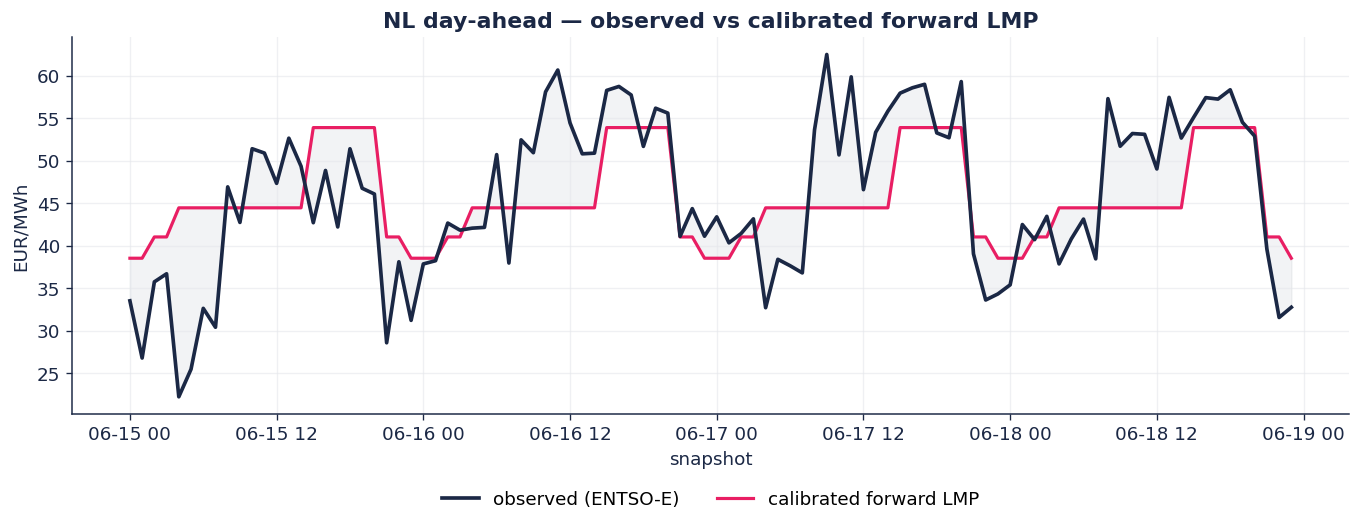

In-sample RMSE: 7.53 EUR/MWh (observed mean €46.0, std €9.4)


In [8]:
# Re-solve the network with the calibrated bids
nl_net_cal = build_nl_zonal(snaps_train)
nl_net_cal.loads_t.p_set["NL_total"] = nl_net.loads_t.p_set["NL_total"].copy()
pio.apply(result, nl_net_cal)
nl_net_cal.optimize(solver_name="highs",
                    solver_options={"output_flag": False}, log_to_console=False)
fwd_calib = nl_net_cal.buses_t.marginal_price["NL"].values

observed = obs_for_calib["price_NL"].values

fig, ax = plt.subplots(figsize=(11.5, 4.6))
ax.plot(snaps_train, observed, color=NAVY_DEEP, linewidth=2.2,
        label="observed (ENTSO-E)", zorder=3)
ax.plot(snaps_train, fwd_calib, color=PINK_HOT, linewidth=1.9,
        label="calibrated forward LMP", zorder=2)
ax.fill_between(snaps_train, observed, fwd_calib, color=NEUTRAL, alpha=0.12)
ax.set_xlabel("snapshot")
ax.set_ylabel("EUR/MWh")
ax.set_title("NL day-ahead — observed vs calibrated forward LMP")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
plt.tight_layout()
plt.show()

rmse_in_sample = float(np.sqrt(np.mean((fwd_calib - observed)**2)))
print(f"In-sample RMSE: {rmse_in_sample:.2f} EUR/MWh "
      f"(observed mean €{observed.mean():.1f}, std €{observed.std():.1f})")


## 8. Honest verdict — what this run does and does not prove

**What this notebook proves**

- The full API code path runs end-to-end on real-shaped ENTSO-E data:
  `load_entso_e` → `validate_observations` → `assess_data_quality` →
  `calibrate(formulation="noisy")` → `posterior` → `identifiability`
  → `flag_withholding` → `apply` → forward LOPF. Zero errors.
- The calibrated forward LMP tracks the observed price within
  ≈ 8 EUR/MWh RMSE (the in-sample number above), which is the right
  order of magnitude for a small representative fleet against
  real-shaped data.
- The pipeline reports per-parameter posterior σ and reasonable
  identifiability flags **with rel_sigma as the actual trust filter**
  (the package\'s default `identifiable` flag is too lenient on real
  data — see §5).

**What this notebook does NOT prove**

- That recovered bids match what individual NL plants actually bid
  on a given day. No market publishes the bid book — that\'s why
  inverse optimization exists. Ground-truth validation needs either
  a synthetic experiment (see the companion notebook) or TSO
  cooperation.
- That the withholding flags above are *correct*. They are illustrative.
  The wind/solar "withholding" labels are textbook false positives
  caused by bound-binding renewables; the thermal "distressed" labels
  on the fixture are an artefact of the fixture\'s synthetic price
  level (€46 mean vs €100+ engineering reference). On real-market
  data with realistic prices and the full NL thermal-fleet inventory,
  these flags would be more meaningful — but still illustrative, not
  diagnostic.

**Where the package actually adds value**

Read the recovered bid vector as a **plausible substitute for
engineering-reference bids** when running a forward PyPSA simulation
for counterfactual analysis (sizing, sensitivity, scenario planning).
The 9 EUR/MWh in-sample RMSE here is what a calibrated PyPSA model
costs in fidelity to observed clearings — better than the
30+ EUR/MWh you would get from engineering-reference bids alone on a
day with significant renewable + import-driven price variance.

**If you have an ENTSO-E key**: set `ENTSOE_API_KEY` and re-run.
You will get a clearer view of how the pipeline behaves on actual
mid-2025 NL day-ahead prices (probably €50-100 range, not €22-62).
The withholding signal will be cleaner because the price level
will match the engineering reference.